# 3W Challenge Baseline: Fault Detection

This notebook provides a reproducible starting point for the binary challenge track. The task is to classify every labeled observation as **normal (`0`) or faulty (`1`)**.

The baseline uses the complete 3W Dataset v2.0.0, the five fixed instance-level validation files, and the agreed cleaning rules. It trains the 3W Toolkit's default decision tree without hyperparameter search. Participants can replace the model and feature engineering, but comparable evaluations must preserve the data, labels, and validation assignments.

## Before you run it

From the repository root, install the project, copy `.env.example` to `.env`, and set the repository and dataset paths described in the challenge README. The complete dataset must contain all 2,228 Parquet instances.

The notebook will:

1. load and validate all five fixed instance lists;
2. remove leading unlabeled rows and fill later label gaps within each instance;
3. map transient labels to their steady classes and combine faults into class `1`;
4. fit Toolkit signal cleaning and mean imputation on each training fold;
5. train a fresh default decision tree, including filled training labels;
6. report validation metrics using only originally observed labels.

In [1]:
import logging
import os
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.metrics import confusion_matrix
from ThreeWToolkit.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Keep notebook output focused while retaining Toolkit warnings and errors.
logging.getLogger("ThreeWToolkit").setLevel(logging.WARNING)

load_dotenv()

REPOSITORY_PATH = Path(os.environ["THREE_W_REPOSITORY_PATH"]).expanduser().resolve()
DATASET_PATH = Path(os.environ["THREE_W_DATASET_PATH"]).expanduser().resolve()
CHALLENGE_PATH = Path(os.environ["THREE_W_CHALLENGE_PATH"]).expanduser().resolve()
SPLIT_DIR = Path(os.environ["THREE_W_CHALLENGE_SPLIT_DIR"]).expanduser().resolve()
RANDOM_SEED = int(os.environ["THREE_W_CHALLENGE_RANDOM_SEED"])

# Make the shared helpers available when Jupyter starts in another directory.
sys.path.insert(0, str(CHALLENGE_PATH))

print(f"Repository: {REPOSITORY_PATH}")
print(f"Dataset:   {DATASET_PATH}")
print(f"Challenge: {CHALLENGE_PATH}")
print(f"Splits:    {SPLIT_DIR}")

Repository: /private/tmp/3w-challenge-upstream.OXe00U
Dataset:   /Users/araujomarins/repos/3W-research/dataset
Challenge: /private/tmp/3w-challenge-upstream.OXe00U/toolkit/demos/challenge
Splits:    /private/tmp/3w-challenge-upstream.OXe00U/toolkit/demos/challenge/splits


## 1. Load every instance from the fixed splits

Each text file defines validation for one run; the other four lists define training. The files are disjoint and their union must contain all 2,228 instances. Building the dataset from that complete union guarantees that no instance is sampled out before evaluation.

In [2]:
def read_validation_lists(split_dir: Path) -> dict[int, set[str]]:
    """Read the five one-path-per-line toolkit file lists."""
    validation_lists = {}
    for split_number in range(1, 6):
        path = split_dir / f"validation_split_{split_number}.txt"
        instances = {
            line.strip()
            for line in path.read_text(encoding="utf-8").splitlines()
            if line.strip()
        }
        validation_lists[split_number] = instances

    all_entries = [
        instance for instances in validation_lists.values() for instance in instances
    ]
    if len(all_entries) != len(set(all_entries)):
        raise ValueError("An instance occurs in more than one validation list.")
    return validation_lists


validation_lists = read_validation_lists(SPLIT_DIR)
instance_files = sorted(set().union(*validation_lists.values()))
if len(instance_files) != 2_228:
    raise ValueError(f"Expected all 2,228 instances, found {len(instance_files):,}.")

print(f"Using {len(instance_files):,} instance files.")
pd.Series(
    {split: len(files) for split, files in validation_lists.items()},
    name="validation_instances",
).to_frame()

Using 2,228 instance files.


,validation_instances
1,446
2,447
3,444
4,446
5,445


## 2. Prepare labels and preserve their origin

The shared [`prepare_instance_labels` helper](challenge_helpers.py) applies the same policy in both notebooks:

1. remove only the consecutive unlabeled rows before the first known label;
2. record which remaining rows have an original label;
3. fill later gaps with the Toolkit's `FillLabelsConfig(fill_method="nearest")`;
4. map transient labels with the Toolkit-configured offset (`105 → 5`) and retain labels `0` through `9`;
5. map class `0` to normal and classes `1` through `9` to faulty.

The Toolkit uses nearest interpolation by row position within each instance, followed by backward/forward fill for any remaining gaps. Trailing gaps are therefore filled too. An entirely unlabeled instance is skipped and counted because no known label is available.

The `label_observed` mask stays in instance metadata, separate from sensor features. Filled labels are available during training, but **every validation metric and confusion matrix excludes those rows**. The original-label mask is recorded before filling and kept aligned when rows are filtered or training is subsampled.

Label preparation uses only the current instance. Signal cleaning and sensor mean imputation are fitted later, using only the current training fold.

In [3]:
from challenge_helpers import (
    load_challenge_samples,
    prepare_fold_data,
    select_observed_predictions,
    split_fold_data,
    train_default_model,
)

In [4]:
print("Loading instances and preparing labels with the Toolkit...", flush=True)
samples, label_counts = load_challenge_samples(
    DATASET_PATH,
    instance_files,
    binary=True,
)
retained_observations = sum(len(event.signal) for event in samples)
display(pd.Series(label_counts, name="observations_or_instances").to_frame())
print(
    f"Retained {retained_observations:,} observations from {len(samples):,} instances."
)
print("Label counts below include filled labels; evaluation uses original labels only.")
pd.concat(
    [event.label for event in samples if event.label is not None],
    ignore_index=True,
).value_counts().sort_index().rename("samples").to_frame()

Loading instances and preparing labels with the Toolkit...


  0%|          | 0/2228 [00:00<?, ?instance/s]

,observations_or_instances
leading_unlabeled_removed,4028400
entirely_unlabeled_instances,0
unsupported_labels_removed,0
imputed_labels_retained,0


Retained 72,558,918 observations from 2,228 instances.
Label counts below include filled labels; evaluation uses original labels only.


,samples
target,
0,17305269
1,55253649


## 3. Prepare signals, train, and evaluate all five splits

The loop below calls separate functions for instance splitting, signal preprocessing, model fitting, and evaluation. Shared data functions live in [`challenge_helpers.py`](challenge_helpers.py); the track-specific metrics remain visible here.

For each split, Toolkit `CleanSignals` thresholds and sensor mean-imputation values are fitted on the complete retained training fold and applied unchanged to validation. A fresh `DecisionTreeClassifier` is trained through `SklearnTrainer` with default hyperparameters and a fixed random seed. There is no hyperparameter search or normalization.

`TRAINING_SAMPLE_STRIDE` is kept at `100` for a practical example. Set it to `1` to train on all retained rows, or `N` for every Nth row within each training instance. Both original and filled training labels are eligible. Preprocessing uses the full training fold regardless of stride. Validation is never subsampled.

Predictions cover all retained validation rows. Before computing any metric, `select_observed_predictions` applies the original-label mask to targets and predictions. `validation_rows` counts all predicted rows, `validation_samples` counts the rows actually scored, and `validation_imputed_labels_excluded` records the difference.

ROC-AUC uses the probability of the faulty class on the scored rows. It is computed separately for each split and included in the mean summary. If those original validation labels contain only one class, ROC-AUC is undefined and reported as `NaN`, which the mean excludes.

The saved outputs below were generated with this label policy and the training stride shown in the code.

In [5]:
# 1 uses every retained training row; N uses every Nth row within each instance.
TRAINING_SAMPLE_STRIDE = 100


def evaluate_validation(trainer, validation_dataset, validation_mask, labels):
    """Score only original labels, including the probability-based ROC-AUC."""
    print("  Predicting validation labels and fault probabilities...", flush=True)
    result = trainer.predict_proba(validation_dataset)
    y_validation, probabilities = select_observed_predictions(result, validation_mask)
    model_classes = np.asarray(trainer.model.model.classes_)
    prediction = model_classes[np.argmax(probabilities, axis=1)]
    fault_columns = np.flatnonzero(model_classes == 1)
    fault_probability = (
        probabilities[:, fault_columns[0]]
        if len(fault_columns)
        else np.zeros(len(y_validation))
    )

    print("  Computing metrics on original validation labels only...", flush=True)
    roc_auc = np.nan
    if np.unique(y_validation).size == 2:
        roc_auc = roc_auc_score(y_validation, fault_probability)
    else:
        print(
            "  ROC-AUC unavailable: scored labels contain only one class.", flush=True
        )

    metrics = {
        "accuracy": accuracy_score(y_validation, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_validation, prediction),
        "macro_f1": f1_score(
            y_validation, prediction, labels=labels, average="macro", zero_division=0
        ),
        "fault_precision": precision_score(y_validation, prediction, zero_division=0),
        "fault_recall": recall_score(y_validation, prediction, zero_division=0),
        "fault_f1": f1_score(y_validation, prediction, zero_division=0),
        "roc_auc": roc_auc,
    }
    return metrics, confusion_matrix(y_validation, prediction, labels=labels)


def evaluate_five_splits(samples, split_files, labels, training_sample_stride):
    """Separate instance splitting, signal preparation, training, and evaluation."""
    rows = []
    aggregate_confusion = np.zeros((len(labels), len(labels)), dtype=int)
    effective_params = None

    for split_number in range(1, 6):
        split_started = perf_counter()
        print(f"\nSplit {split_number}/5", flush=True)

        # 1. Select whole instances; their labels were prepared during loading.
        raw_train, raw_validation = split_fold_data(samples, split_files[split_number])

        # 2. Fit signal preprocessing on training and keep validation provenance.
        train, validation, validation_mask, counts = prepare_fold_data(
            raw_train, raw_validation, training_sample_stride
        )

        # 3. Train a fresh model, including filled labels at the chosen stride.
        trainer = train_default_model(train, RANDOM_SEED)
        effective_params = dict(trainer.model.get_params())

        # 4. Predict all retained validation rows, then score only original labels.
        metrics, fold_confusion = evaluate_validation(
            trainer, validation, validation_mask, labels
        )
        rows.append({"split": split_number, **counts, **metrics})
        aggregate_confusion += fold_confusion

        scores = ", ".join(f"{name}={value:.4f}" for name, value in metrics.items())
        print(
            f"  Complete in {perf_counter() - split_started:,.1f}s: {scores}",
            flush=True,
        )

    return pd.DataFrame(rows), aggregate_confusion, effective_params

In [6]:
fold_results, aggregate_confusion, effective_params = evaluate_five_splits(
    samples,
    validation_lists,
    labels=[0, 1],
    training_sample_stride=TRAINING_SAMPLE_STRIDE,
)
display(fold_results.round(4))
display(fold_results.mean(numeric_only=True).rename("five_split_mean").to_frame())

print("DecisionTree parameters used in every split (no search):")
effective_params


Split 1/5


  Training rows: 575,850 of 57,542,510 available (stride=100); 0 have filled labels.


  Validation rows: 15,016,408; scoring 15,016,408 original labels; excluding 0 filled labels.


  Fitting Toolkit signal cleaning and mean imputation on training...


  Training the decision tree...


...

  Complete in 94.6s: accuracy=0.9298, balanced_accuracy=0.9079, macro_f1=0.9031, fault_precision=0.9591, fault_recall=0.9489, fault_f1=0.9540, roc_auc=0.9058


,split,available_train_samples,train_samples,train_imputed_labels,validation_rows,validation_samples,validation_imputed_labels_excluded,accuracy,balanced_accuracy,macro_f1,fault_precision,fault_recall,fault_f1,roc_auc
0,1,57542510,575850,0,15016408,15016408,0,0.9127,0.9123,0.8868,0.9706,0.9130,0.9409,0.9125
1,2,58546283,585886,0,14012635,14012635,0,0.8889,0.8344,0.8461,0.9121,0.9430,0.9273,0.8345
2,3,58443490,584855,0,14115428,14115428,0,0.9003,0.8890,0.8660,0.9591,0.9097,0.9338,0.8886
3,4,57426829,574693,0,15132089,15132089,0,0.9303,0.8974,0.9041,0.9468,0.9618,0.9543,0.8955
4,5,58276560,583188,0,14282358,14282358,0,0.9298,0.9079,0.9031,0.9591,0.9489,0.9540,0.9058


,five_split_mean
split,3.000000e+00
available_train_samples,5.804713e+07
train_samples,5.808944e+05
train_imputed_labels,0.000000e+00
validation_rows,1.451178e+07
validation_samples,1.451178e+07
validation_imputed_labels_excluded,0.000000e+00
accuracy,9.124012e-01
balanced_accuracy,8.881870e-01
macro_f1,8.812006e-01


DecisionTree parameters used in every split (no search):


{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

## 4. Aggregate the confusion matrices

Each confusion matrix uses only originally labeled validation rows. Summing the five disjoint folds produces a pooled out-of-fold result without filled labels. Row normalization shows the prediction distribution within each true class; its diagonal is per-class recall.

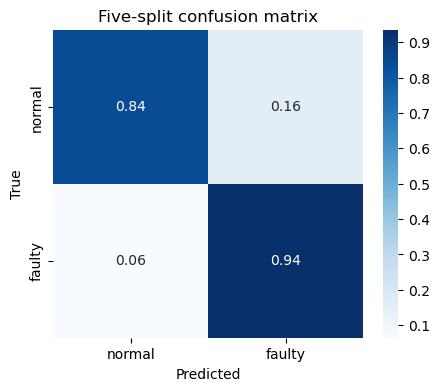

In [7]:
row_totals = aggregate_confusion.sum(axis=1, keepdims=True)
normalized_confusion = np.divide(
    aggregate_confusion,
    row_totals,
    out=np.zeros_like(aggregate_confusion, dtype=float),
    where=row_totals != 0,
)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    normalized_confusion,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["normal", "faulty"],
    yticklabels=["normal", "faulty"],
    ax=ax,
)
ax.set(xlabel="Predicted", ylabel="True", title="Five-split confusion matrix")
plt.show()